# Stakes Kernel Timing Analysis

Stakes-focused notebook for the `Juananalysis` kernel-regression workflow. It supports:

- one selected animal with overlays by ramp duration
- all selected animals with one hierarchical average curve per ramp duration
- kernel-based tachometric curves, MT-vs-RT curves, RT density, and RT CDF plots

Run the notebook top to bottom the first time. After that, you can usually just change the config cell and rerun the compute + plot cells.


## Repo Setup

Run this first. It makes imports and data paths work whether the notebook is launched from the repo root or from inside `notebooks/Stakes`.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "analysis" / "daily_merge.py").exists() and (candidate / "DataFiles").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find the Mafalda_analysis repo root from the current working directory."
    )

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

ROOT

PosixPath('/Users/mafaldavalente/Documents/Mafalda_analysis')

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import Helpers.DataHelpers as DataHelpers
from analysis.datasets import DatasetSpec, load_dataset_selections
from Juananalysis.load_data import load_behavior_csv
from Juananalysis.plot_results import shaded_curve
from Juananalysis.kernel_regression import (
    build_hierarchical_data_full,
    epanechnikov_kernel,
    hierarchical_bootstrap_joint,
    kreg_for_aggregate,
)


## Configuration

This is the main cell to edit.

Notes:
- `ANALYSIS_MODE` switches between one-animal and all-animal workflows.
- Stakes `cohort2` currently only contains `session_type == 1`, `stim_dur == 6000`, and training levels `1..7`.
- The training and ramp filters below follow the same pattern used in the other Stakes notebooks.
- In both modes, curves are split by `sound_ramp_time`.
- In `all_animals` mode, the notebook computes one hierarchical average curve per ramp duration across all selected animals.
- Unless you explicitly ask otherwise, this notebook should never flatten all trials and treat them as if they came from one animal.
- Set `SINGLE_SUBJECT_FIXED_ABL = 20` if you want one ABL with ramp-based overlays.


In [3]:
ANALYSIS_MODE = "all_animals"   # "single_subject" or "all_animals"

LINE = "Stakes"
COHORT = "cohort2"

ANIMAL = "JCS0013"              # used only in single_subject mode
SINGLE_SUBJECT_SPLIT_COL = "sound_ramp_time"
SPLIT_VALUES = None                # None = infer available ramp values after filtering

TRAINING_LEVEL = None
TRAINING_LEVEL_MIN = 6
TRAINING_LEVEL_MAX = 8             # keep levels < 8, matching the current Stakes dataset (1..7)
ABL_FILTER = None                  # e.g. 20 or [20, 30]
SOUND_RAMP_FILTER = None           # e.g. [0.005, 0.02]
SOUND_RAMP_EXCLUDE = [0.005, 0.02]          # e.g. [0.5]
SINGLE_SUBJECT_FIXED_ABL = 20      # use one ABL for ramp overlays; set None to keep all ABLs

DROP_REPEAT_TRIALS = True
NORMALIZE_STAKES = True
EASY_VALUE = None                  # None, 0, or 1
SHOW_SOURCE_SUMMARY = False        # True = print raw file contents before filtering

XXI = np.linspace(0.0, 1.0, 200)
RTD_XXI = np.linspace(-0.3, 1.0, 260)
BANDWIDTH = 0.015 if ANALYSIS_MODE == "all_animals" else 0.02
BOOTSTRAPS = 1000 if ANALYSIS_MODE == "all_animals" else 800
XMIN, XMAX = 0.0, 0.5
RTD_XMIN, RTD_XMAX = -0.3, 0.5

RAMP_COLORS = {
    0.005: "tab:blue",
    0.02: "tab:green",
    0.1: "tab:orange",
    0.2: "tab:red",
    0.5: "tab:purple",
}

if ANALYSIS_MODE not in {"single_subject", "all_animals"}:
    raise ValueError("ANALYSIS_MODE must be 'single_subject' or 'all_animals'.")

print({
    "line": LINE,
    "cohort": COHORT,
    "analysis_mode": ANALYSIS_MODE,
    "animal": ANIMAL,
    "single_subject_split_col": SINGLE_SUBJECT_SPLIT_COL,
    "single_subject_fixed_abl": SINGLE_SUBJECT_FIXED_ABL,
    "split_values": SPLIT_VALUES,
    "training_level": TRAINING_LEVEL,
    "training_level_min": TRAINING_LEVEL_MIN,
    "training_level_max": TRAINING_LEVEL_MAX,
    "abl_filter": ABL_FILTER,
    "sound_ramp_filter": SOUND_RAMP_FILTER,
    "sound_ramp_exclude": SOUND_RAMP_EXCLUDE,
    "easy_value": EASY_VALUE,
    "show_source_summary": SHOW_SOURCE_SUMMARY,
    "bandwidth": BANDWIDTH,
    "bootstraps": BOOTSTRAPS,
    "rtd_x_range": (RTD_XMIN, RTD_XMAX),
})


{'line': 'Stakes', 'cohort': 'cohort2', 'analysis_mode': 'all_animals', 'animal': 'JCS0013', 'single_subject_split_col': 'sound_ramp_time', 'single_subject_fixed_abl': 20, 'split_values': None, 'training_level': None, 'training_level_min': 6, 'training_level_max': 8, 'abl_filter': None, 'sound_ramp_filter': None, 'sound_ramp_exclude': [0.005, 0.02], 'easy_value': None, 'show_source_summary': False, 'bandwidth': 0.015, 'bootstraps': 1000, 'rtd_x_range': (-0.3, 0.5)}


## Load Cohort Data

In [4]:
spec = DatasetSpec(line=LINE, cohort=COHORT, base_dir=str(ROOT / "DataFiles"))

df_raw, meta_df, info = load_dataset_selections(
    selections=[spec],
    base_dir=str(ROOT / "DataFiles"),
    require_meta=False,
)

dataset_key = info["dataset_keys"][0]
used_csv = info["used_csvs"][dataset_key]

print("Dataset:", dataset_key)
print("CSV:", used_csv)

if SHOW_SOURCE_SUMMARY:
    raw_animals = sorted(df_raw["animal"].astype(str).str.strip().dropna().unique().tolist()) if "animal" in df_raw.columns else []
    raw_training_levels = sorted(pd.to_numeric(df_raw.get("training_level"), errors="coerce").dropna().unique().tolist()) if "training_level" in df_raw.columns else []
    raw_abls = sorted(pd.to_numeric(df_raw.get("ABL"), errors="coerce").dropna().unique().tolist()) if "ABL" in df_raw.columns else []
    raw_ramps = sorted(pd.to_numeric(df_raw.get("sound_ramp_time"), errors="coerce").dropna().unique().tolist()) if "sound_ramp_time" in df_raw.columns else []
    print("Source rows:", len(df_raw))
    print("Source animals:", len(raw_animals), raw_animals)
    print("Source training levels:", raw_training_levels)
    print("Source ABLs:", raw_abls)
    print("Source ramps:", raw_ramps)
    print("Metadata rows:", len(meta_df))

    source_summary = pd.DataFrame({
        "metric": ["rows", "animals", "training_levels", "ABLs", "ramps", "metadata_rows"],
        "value": [
            len(df_raw),
            len(raw_animals),
            raw_training_levels,
            raw_abls,
            raw_ramps,
            len(meta_df),
        ],
    })
    display(source_summary)


Dataset: Stakes:cohort2
CSV: /Users/mafaldavalente/Documents/Mafalda_analysis/DataFiles/Stakes_cohort2/merged_all_subjects.csv


## Prepare Analysis Table

In [5]:
df = load_behavior_csv(used_csv)
df = DataHelpers.prepare_data(df, session_col="session", trial_col="trial")

meta_path = ROOT / "DataFiles" / f"{LINE}_{COHORT}" / "sex_gen.csv"
df = DataHelpers.restrict_subjects(
    df,
    meta_csv=str(meta_path),
    sex=None,
    genotypes=None,
    attach_meta=True,
)

df["animal"] = df["animal"].astype(str).str.strip()

if NORMALIZE_STAKES:
    df = DataHelpers.normalize_stakes_abl(df)
    df = DataHelpers.normalize_stakes_sound_ramp(df)

if DROP_REPEAT_TRIALS and "trial_is_repeat" in df.columns:
    df = df[df["trial_is_repeat"] == False].copy()

training_num = pd.to_numeric(df.get("training_level"), errors="coerce")
if TRAINING_LEVEL is not None:
    df = df[training_num == TRAINING_LEVEL].copy()
elif TRAINING_LEVEL_MIN is not None or TRAINING_LEVEL_MAX is not None:
    if TRAINING_LEVEL_MIN is not None:
        df = df[training_num >= TRAINING_LEVEL_MIN].copy()
        training_num = pd.to_numeric(df.get("training_level"), errors="coerce")
    if TRAINING_LEVEL_MAX is not None:
        df = df[training_num < TRAINING_LEVEL_MAX].copy()

if ABL_FILTER is not None and "ABL" in df.columns:
    abl_num = pd.to_numeric(df["ABL"], errors="coerce")
    wanted_abl = pd.to_numeric(pd.Series(ABL_FILTER if isinstance(ABL_FILTER, (list, tuple, set)) else [ABL_FILTER]), errors="coerce").dropna().tolist()
    df = df[abl_num.isin(wanted_abl)].copy()

if SOUND_RAMP_FILTER is not None and "sound_ramp_time" in df.columns:
    ramp_num = pd.to_numeric(df["sound_ramp_time"], errors="coerce")
    wanted_ramps = pd.to_numeric(pd.Series(SOUND_RAMP_FILTER if isinstance(SOUND_RAMP_FILTER, (list, tuple, set)) else [SOUND_RAMP_FILTER]), errors="coerce").dropna().tolist()
    df = df[ramp_num.isin(wanted_ramps)].copy()

if SOUND_RAMP_EXCLUDE is not None and "sound_ramp_time" in df.columns:
    ramp_num = pd.to_numeric(df["sound_ramp_time"], errors="coerce")
    excluded_ramps = pd.to_numeric(pd.Series(SOUND_RAMP_EXCLUDE if isinstance(SOUND_RAMP_EXCLUDE, (list, tuple, set)) else [SOUND_RAMP_EXCLUDE]), errors="coerce").dropna().tolist()
    df = df[~ramp_num.isin(excluded_ramps)].copy()

if SINGLE_SUBJECT_FIXED_ABL is not None:
    df = df[pd.to_numeric(df["ABL"], errors="coerce") == SINGLE_SUBJECT_FIXED_ABL].copy()

if SINGLE_SUBJECT_SPLIT_COL not in df.columns:
    raise KeyError(f"Missing split column: {SINGLE_SUBJECT_SPLIT_COL!r}")
split_series = pd.to_numeric(df[SINGLE_SUBJECT_SPLIT_COL], errors="coerce")
SPLIT_VALUES = sorted(split_series.dropna().unique().tolist()) if SPLIT_VALUES is None else SPLIT_VALUES

valid_mask = df["RT"].notna() & df["Out"].notna() & df["MT"].notna()
abort_type = df.get("abort_type", pd.Series(index=df.index, dtype=object)).astype("string").str.strip()
rtd_abort_mask = df["RT"].notna() & abort_type.isin(["Fixation", "RT-"])

df_valid = df[valid_mask].copy()
df_rtd = df[valid_mask | rtd_abort_mask].copy()

if ANALYSIS_MODE == "single_subject":
    if ANIMAL not in set(df_valid["animal"].astype(str)):
        raise ValueError(f"Animal {ANIMAL!r} is not present after filtering.")

print("Selected rows (all kept trials):", len(df))
print("Valid rows for tachometric / MT / CDF:", len(df_valid))
print("RT-density rows (valid + Fixation/RT- aborts):", len(df_rtd))
print("Animals:", df_valid["animal"].nunique() if "animal" in df_valid.columns else 0)
print("Animal ids:", sorted(df_valid["animal"].dropna().astype(str).unique().tolist()) if "animal" in df_valid.columns else [])
print("Training levels:", sorted(pd.to_numeric(df_valid["training_level"], errors="coerce").dropna().unique().tolist()) if "training_level" in df_valid.columns else [])
print("ABLs:", sorted(pd.to_numeric(df_valid["ABL"], errors="coerce").dropna().unique().tolist()) if "ABL" in df_valid.columns else [])
if "sound_ramp_time" in df_valid.columns:
    print("Ramp durations:", sorted(pd.to_numeric(df_valid["sound_ramp_time"], errors="coerce").dropna().unique().tolist()))
print("Session types:", sorted(pd.to_numeric(df_valid["session_type"], errors="coerce").dropna().unique().tolist()) if "session_type" in df_valid.columns else [])
print("Stim durations:", sorted(pd.to_numeric(df_valid["stim_dur"], errors="coerce").dropna().unique().tolist()) if "stim_dur" in df_valid.columns else [])
print("Split values:", SPLIT_VALUES)

if ANALYSIS_MODE == "single_subject":
    print("Single-subject mode for:", ANIMAL)
else:
    print("All-animals mode: computing one hierarchical average curve per ramp across selected animals.")

df_valid.head()


Rename map used: {'timed_rt': 'RT', 'timed_mt': 'MT'}
Columns with 'timed': ['timed_lnp', 'timed_opto_onset_time']
RT in columns after rename? True
MT in columns after rename? True
Selected rows (all kept trials): 81316
Valid rows for tachometric / MT / CDF: 48458
RT-density rows (valid + Fixation/RT- aborts): 71561
Animals: 9
Animal ids: ['JCS0014', 'JCS0015', 'JCS0016', 'JCS0017', 'JCS0018', 'JCS0019', 'JCS0020', 'JCS0021', 'JCS0022']
Training levels: [7]
ABLs: [20.0]
Ramp durations: [0.1, 0.2, 0.5]
Session types: [1]
Stim durations: [6000]
Split values: [0.1, 0.2, 0.5]
All-animals mode: computing one hierarchical average curve per ramp across selected animals.


,animal,batch,experimenter,version,bias,repeated_trial,trial,trial_start,tared_trial_start,trial_end,...,Sign,absILD,Easy,Rsp,Rsp_R,Out,LED,trial_is_repeat,sex,genotype
35968,JCS0018,stakes,MV,0.11.1,0.00,False,2050,3.867478e+09,3290.324000,3.867478e+09,...,1.0,1.0,0,-3.0,-1.0,1.0,0,False,female,wt
35969,JCS0018,stakes,MV,0.11.1,0.04,False,2051,3.867478e+09,3294.292000,3.867478e+09,...,1.0,16.0,1,-3.0,-1.0,1.0,0,False,female,wt
35972,JCS0018,stakes,MV,0.11.1,-0.08,False,2054,3.867478e+09,3317.352000,3.867478e+09,...,1.0,1.0,0,-7.0,-3.0,0.0,0,False,female,wt
35974,JCS0018,stakes,MV,0.11.1,-0.12,False,2056,3.867478e+09,3345.652992,3.867478e+09,...,-1.0,1.0,0,-3.0,-1.0,0.0,0,False,female,wt
35975,JCS0018,stakes,MV,0.11.1,-0.08,False,2057,3.867478e+09,3365.416992,3.867478e+09,...,1.0,4.0,0,-3.0,-1.0,1.0,0,False,female,wt


## Quick Cohort Check

In [6]:
animal_summary = pd.DataFrame()
if "animal" in df_valid.columns:
    animal_summary = (
        df_valid.assign(
            training_level_num=pd.to_numeric(df_valid.get("training_level"), errors="coerce"),
            ramp_num=pd.to_numeric(df_valid.get("sound_ramp_time"), errors="coerce"),
            abl_num=pd.to_numeric(df_valid.get("ABL"), errors="coerce"),
            session_num=pd.to_numeric(df_valid.get("session"), errors="coerce"),
        )
        .groupby("animal", dropna=False)
        .agg(
            trials=("animal", "size"),
            sessions=("session_num", "nunique"),
            ramps=("ramp_num", lambda s: sorted(s.dropna().unique().tolist())),
            abls=("abl_num", lambda s: sorted(s.dropna().unique().tolist())),
            training_levels=("training_level_num", lambda s: sorted(s.dropna().unique().tolist())),
        )
        .reset_index()
        .sort_values("animal")
        .reset_index(drop=True)
    )

display(animal_summary)


def build_hierarchical_rtd_data(df_in, group_col, group_value, *, easy_value=None, abl_value=None):
    mask = (
        df_in[group_col].notna()
        & (df_in[group_col] == group_value)
        & df_in["RT"].notna()
    )
    if easy_value is not None and "Easy" in df_in.columns:
        mask &= df_in["Easy"] == easy_value
    if abl_value is not None and "ABL" in df_in.columns:
        mask &= pd.to_numeric(df_in["ABL"], errors="coerce") == abl_value

    sub = df_in.loc[mask].copy()
    if sub.empty:
        return []

    animals_data = []
    for animal in sub["animal"].dropna().unique():
        sub_a = sub[sub["animal"] == animal]
        sessions_data = []
        for session in sub_a["session"].dropna().unique():
            sub_s = sub_a[sub_a["session"] == session].copy()
            if sub_s.empty:
                continue
            if "ILD" in sub_s.columns:
                stim_key = sub_s["ILD"].where(sub_s["ILD"].notna(), "__nan__")
            else:
                stim_key = pd.Series("all", index=sub_s.index)
            sub_s = sub_s.assign(_stim_key=stim_key)
            stimuli_data = []
            for stim in sub_s["_stim_key"].unique():
                rt_arr = sub_s.loc[sub_s["_stim_key"] == stim, "RT"].to_numpy()
                if len(rt_arr) > 0:
                    stimuli_data.append(rt_arr)
            if stimuli_data:
                sessions_data.append(stimuli_data)
        if sessions_data:
            animals_data.append(sessions_data)
    return animals_data


def hierarchical_bootstrap_rtd(data_nested, xxi, h, B):
    n_grid = len(xxi)
    Zden = np.zeros((B, n_grid))
    n_animals = len(data_nested)

    if n_animals == 0:
        nan = np.full(n_grid, np.nan)
        return nan, nan, nan

    if n_animals == 1:
        flat_rts = []
        for session_trials in data_nested[0]:
            for rt_arr in session_trials:
                flat_rts.append(rt_arr)
        x_all = np.concatenate(flat_rts)
        for b in range(B):
            idx = np.random.randint(0, len(x_all), size=len(x_all))
            x = x_all[idx]
            z = (xxi[None, :] - x[:, None]) / h
            Kz = epanechnikov_kernel(z)
            Zden[b, :] = Kz.sum(axis=0) / (len(x) * h) + 1e-12
    else:
        for b in range(B):
            RTs_all = []
            animal_indices = np.random.randint(0, n_animals, size=n_animals)
            for ai in animal_indices:
                sessions = data_nested[ai]
                if not sessions:
                    continue
                sess_indices = np.random.randint(0, len(sessions), size=len(sessions))
                for si in sess_indices:
                    stimuli = sessions[si]
                    if not stimuli:
                        continue
                    stim_indices = np.random.randint(0, len(stimuli), size=len(stimuli))
                    for gi in stim_indices:
                        rt_arr = stimuli[gi]
                        n_trials = len(rt_arr)
                        if n_trials == 0:
                            continue
                        trial_idx = np.random.randint(0, n_trials, size=n_trials)
                        RTs_all.append(rt_arr[trial_idx])
            if RTs_all:
                x = np.concatenate(RTs_all)
                z = (xxi[None, :] - x[:, None]) / h
                Kz = epanechnikov_kernel(z)
                Zden[b, :] = Kz.sum(axis=0) / (len(x) * h) + 1e-12
            else:
                Zden[b, :] = np.nan

    med = np.nanmedian(Zden, axis=0)
    q_hi = np.nanquantile(Zden, 0.975, axis=0)
    q_lo = np.nanquantile(Zden, 0.025, axis=0)
    return med, q_hi - med, med - q_lo


,animal,trials,sessions,ramps,abls,training_levels
0,JCS0014,5193,19,"[0.1, 0.2, 0.5]",[20.0],[7]
1,JCS0015,4704,20,"[0.1, 0.2, 0.5]",[20.0],[7]
2,JCS0016,3427,12,"[0.1, 0.2, 0.5]",[20.0],[7]
3,JCS0017,5254,21,"[0.1, 0.2, 0.5]",[20.0],[7]
4,JCS0018,5669,21,"[0.1, 0.2, 0.5]",[20.0],[7]
5,JCS0019,5606,18,"[0.1, 0.2, 0.5]",[20.0],[7]
6,JCS0020,6366,20,"[0.1, 0.2, 0.5]",[20.0],[7]
7,JCS0021,5300,21,"[0.1, 0.2, 0.5]",[20.0],[7]
8,JCS0022,6939,21,"[0.1, 0.2, 0.5]",[20.0],[7]


## Run Kernel Analysis

In [7]:
if ANALYSIS_MODE == "all_animals":
    df_valid_all = df_valid.copy()
    df_valid_all["analysis_group"] = pd.to_numeric(df_valid_all[SINGLE_SUBJECT_SPLIT_COL], errors="coerce")
    df_rtd_all = df_rtd.copy()
    df_rtd_all["analysis_group"] = pd.to_numeric(df_rtd_all[SINGLE_SUBJECT_SPLIT_COL], errors="coerce")

    _RTD_valid_unused, TCM_all, CDF_all, MT_all = kreg_for_aggregate(
        df_valid_all,
        xxi=XXI,
        h=BANDWIDTH,
        B=BOOTSTRAPS,
        group_col="analysis_group",
        group_values=SPLIT_VALUES,
        easy_value=EASY_VALUE,
        abl_value=None,
    )

    RTD_all = {}
    for split_value in SPLIT_VALUES:
        data_nested_rtd = build_hierarchical_rtd_data(
            df_rtd_all,
            group_col="analysis_group",
            group_value=split_value,
            easy_value=EASY_VALUE,
            abl_value=None,
        )
        RTD_all[split_value] = hierarchical_bootstrap_rtd(
            data_nested_rtd,
            RTD_XXI,
            BANDWIDTH,
            BOOTSTRAPS,
        )

    print("Finished all-animals kernel regression with one hierarchical average curve per ramp.")
    print("RT density uses valid trials plus Fixation/RT- aborts with measured RT.")
else:
    df_subject_valid = df_valid[df_valid["animal"] == ANIMAL].copy()
    df_subject_rtd = df_rtd[df_rtd["animal"] == ANIMAL].copy()
    RTD_all = {}
    TCM_all = {}
    CDF_all = {}
    MT_all = {}

    for split_value in SPLIT_VALUES:
        split_valid = pd.to_numeric(df_subject_valid[SINGLE_SUBJECT_SPLIT_COL], errors="coerce")
        df_split_valid = df_subject_valid[split_valid == split_value].copy()
        if df_split_valid.empty:
            RTD_all[split_value] = None
            TCM_all[split_value] = None
            CDF_all[split_value] = None
            MT_all[split_value] = None
            continue

        data_nested_valid = build_hierarchical_data_full(
            df_split_valid,
            group_col="animal",
            group_value=ANIMAL,
            easy_value=EASY_VALUE,
            abl_value=None,
        )
        _RTD_valid_unused, TCM_all[split_value], CDF_all[split_value], MT_all[split_value] = hierarchical_bootstrap_joint(
            data_nested_valid,
            XXI,
            BANDWIDTH,
            BOOTSTRAPS,
        )

        split_rtd = pd.to_numeric(df_subject_rtd[SINGLE_SUBJECT_SPLIT_COL], errors="coerce")
        df_split_rtd = df_subject_rtd[split_rtd == split_value].copy()
        data_nested_rtd = build_hierarchical_rtd_data(
            df_split_rtd,
            group_col="animal",
            group_value=ANIMAL,
            easy_value=EASY_VALUE,
            abl_value=None,
        )
        RTD_all[split_value] = hierarchical_bootstrap_rtd(
            data_nested_rtd,
            RTD_XXI,
            BANDWIDTH,
            BOOTSTRAPS,
        )

    print(f"Finished single-subject kernel regression for {ANIMAL}.")
    print("RT density uses valid trials plus Fixation/RT- aborts with measured RT.")


Finished all-animals kernel regression with one hierarchical average curve per ramp.
RT density uses valid trials plus Fixation/RT- aborts with measured RT.


## Plot Helpers

In [8]:
def color_for_key(key):
    return RAMP_COLORS.get(key, None)


def label_for_key(key):
    return f"ramp {key * 1000:.0f} ms"


def iter_result_keys(results):
    return SPLIT_VALUES


def plot_curve_bundle(results, *, ylabel, title, ylim=None, xgrid=None, xlim=None):
    fig, ax = plt.subplots(figsize=(7, 4))
    grid = XXI if xgrid is None else xgrid

    for key in iter_result_keys(results):
        bundle = results.get(key)
        if bundle is None:
            continue
        med, up, dn = bundle
        if med is None or np.isnan(med).all():
            continue
        shaded_curve(grid, med, up, dn, color=color_for_key(key), label=label_for_key(key))

    ax.set_xlabel("RT (s)")
    ax.set_ylabel(ylabel)
    ax.set_xlim(*(xlim if xlim is not None else (XMIN, XMAX)))
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis="x", linestyle=":", alpha=0.5)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


## Tachometric Curves

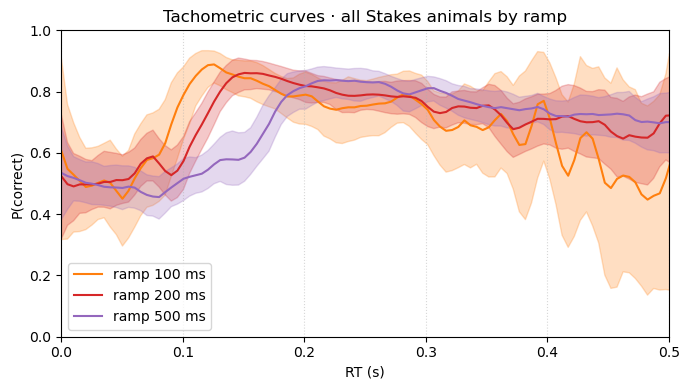

In [9]:
title = "Tachometric curves · all Stakes animals by ramp" if ANALYSIS_MODE == "all_animals" else f"Tachometric curves · {ANIMAL}"
plot_curve_bundle(TCM_all, ylabel="P(correct)", title=title, ylim=(0, 1))

## MT vs RT

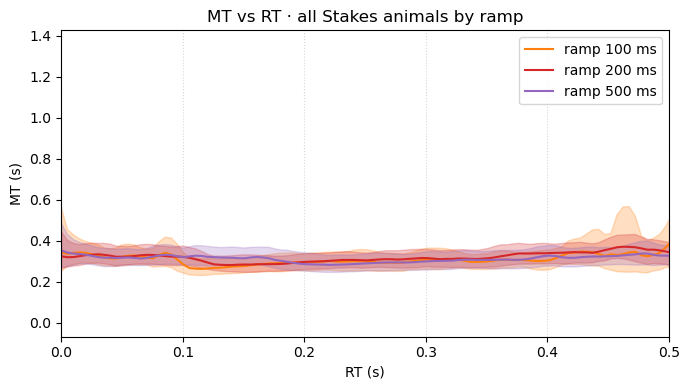

In [10]:
title = "MT vs RT · all Stakes animals by ramp" if ANALYSIS_MODE == "all_animals" else f"MT vs RT · {ANIMAL}"
plot_curve_bundle(MT_all, ylabel="MT (s)", title=title)

## RT Density

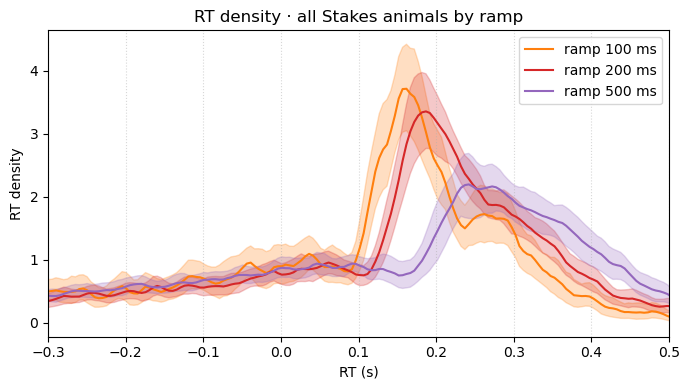

In [11]:
title = "RT density · all Stakes animals by ramp" if ANALYSIS_MODE == "all_animals" else f"RT density · {ANIMAL}"
plot_curve_bundle(RTD_all, ylabel="RT density", title=title, xgrid=RTD_XXI, xlim=(RTD_XMIN, RTD_XMAX))


## RT CDF

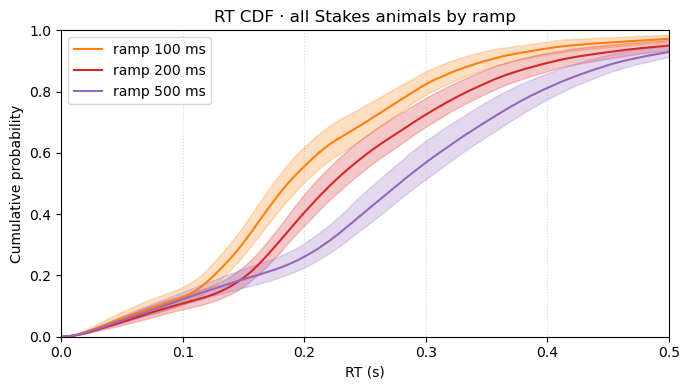

In [12]:
title = "RT CDF · all Stakes animals by ramp" if ANALYSIS_MODE == "all_animals" else f"RT CDF · {ANIMAL}"
plot_curve_bundle(CDF_all, ylabel="Cumulative probability", title=title, ylim=(0, 1))

## Optional: Save Figures

Uncomment and run if you want PNG copies in `outputs/kernel_timing/`.

In [ ]:
# from pathlib import Path
# out_dir = ROOT / "outputs" / "kernel_timing"
# out_dir.mkdir(parents=True, exist_ok=True)
# for i, fig_num in enumerate(plt.get_fignums(), start=1):
#     fig = plt.figure(fig_num)
#     suffix = ANIMAL if ANALYSIS_MODE == "single_subject" else COHORT_KEY.lower()
#     fig.savefig(out_dir / f"kernel_timing_{ANALYSIS_MODE}_{suffix}_{i:02d}.png", dpi=200, bbox_inches="tight")